# 03. Modelos CART

Este cuaderno entrena y evalúa árboles CART para clasificación y regresión. La clasificación utiliza **Bank Marketing** sin `duration`, mientras que la regresión emplea la serie temporal preprocesada de consumo eléctrico.


#### Índice

1. Librerías utilizadas.
2. Carga y preparación de los datos.
3. CART para clasificación.
4. CART para regresión.
5. Guardado de resultados.


## 1. Librerías utilizadas


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, ParameterGrid
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

## 2. Carga y preparación de los datos

En este bloque se cargan los conjuntos previamente procesados de clasificación y regresión. Para **Bank Marketing** se utiliza exclusivamente el escenario sin `duration`: se separa la variable objetivo, se imputan los valores perdidos y se codifican las variables categóricas mediante variables indicadoras. En el problema de consumo eléctrico, se separa la variable objetivo horaria y se conservan los predictores creados durante el preprocesamiento.


In [2]:
bank_train = pd.read_csv("../../data/processed/serie_computacional/bank_train_sin_duration.csv")
bank_test = pd.read_csv("../../data/processed/serie_computacional/bank_test_sin_duration.csv")

power_train = pd.read_csv(
    "../../data/processed/serie_computacional/power_train_hourly.csv",
    parse_dates=["datetime"]
)

power_test = pd.read_csv(
    "../../data/processed/serie_computacional/power_test_hourly.csv",
    parse_dates=["datetime"]
)

objetivo_clasificacion = "y"
objetivo_regresion = "Global_active_energy_kwh"

assert "duration" not in bank_train.columns
assert "duration" not in bank_test.columns
assert objetivo_clasificacion in bank_train.columns
assert objetivo_clasificacion in bank_test.columns
assert objetivo_regresion in power_train.columns
assert objetivo_regresion in power_test.columns

X_train_bank = bank_train.drop(columns=[objetivo_clasificacion]).copy()
y_train_bank = bank_train[objetivo_clasificacion].copy()
X_test_bank = bank_test.drop(columns=[objetivo_clasificacion]).copy()
y_test_bank = bank_test[objetivo_clasificacion].copy()

if not pd.api.types.is_numeric_dtype(y_train_bank):
    y_train_bank = y_train_bank.map({"no": 0, "yes": 1})
    y_test_bank = y_test_bank.map({"no": 0, "yes": 1})

y_train_bank = y_train_bank.astype(int)
y_test_bank = y_test_bank.astype(int)

variables_numericas_bank = [
    col for col in X_train_bank.columns
    if pd.api.types.is_numeric_dtype(X_train_bank[col])
]

variables_categoricas_bank = [
    col for col in X_train_bank.columns
    if col not in variables_numericas_bank
]

for col in variables_numericas_bank:
    mediana = X_train_bank[col].median()
    X_train_bank[col] = X_train_bank[col].fillna(mediana)
    X_test_bank[col] = X_test_bank[col].fillna(mediana)

for col in variables_categoricas_bank:
    X_train_bank[col] = X_train_bank[col].fillna("missing")
    X_test_bank[col] = X_test_bank[col].fillna("missing")

datos_bank = pd.concat([X_train_bank, X_test_bank], axis=0)
datos_bank = pd.get_dummies(datos_bank, columns=variables_categoricas_bank)

X_train_bank_modelo = datos_bank.iloc[:len(X_train_bank)].copy()
X_test_bank_modelo = datos_bank.iloc[len(X_train_bank):].copy()

X_train_power = power_train.drop(columns=[objetivo_regresion, "datetime"]).copy()
y_train_power = power_train[objetivo_regresion].copy()

X_test_power = power_test.drop(columns=[objetivo_regresion, "datetime"]).copy()
y_test_power = power_test[objetivo_regresion].copy()

variables_numericas_power = list(X_train_power.columns)

for col in variables_numericas_power:
    mediana = X_train_power[col].median()
    X_train_power[col] = X_train_power[col].fillna(mediana)
    X_test_power[col] = X_test_power[col].fillna(mediana)

resumen_datos = pd.DataFrame([
    {
        "dataset": "Bank Marketing",
        "problema": "clasificación",
        "train": len(bank_train),
        "test": len(bank_test),
        "variables_originales": X_train_bank.shape[1],
        "variables_modelo": X_train_bank_modelo.shape[1],
        "variables_numericas": len(variables_numericas_bank),
        "variables_categoricas": len(variables_categoricas_bank),
        "objetivo": objetivo_clasificacion,
    },
    {
        "dataset": "Consumo eléctrico",
        "problema": "regresión temporal",
        "train": len(power_train),
        "test": len(power_test),
        "variables_originales": X_train_power.shape[1],
        "variables_modelo": X_train_power.shape[1],
        "variables_numericas": len(variables_numericas_power),
        "variables_categoricas": 0,
        "objetivo": objetivo_regresion,
    },
])

resumen_datos

,dataset,problema,train,test,variables_originales,variables_modelo,variables_numericas,variables_categoricas,objetivo
0,Bank Marketing,clasificación,36168,9043,15,50,6,9,y
1,Consumo eléctrico,regresión temporal,27133,6784,14,14,14,0,Global_active_energy_kwh


## 3. CART para clasificación

La búsqueda de hiperparámetros se realiza mediante validación cruzada estratificada sobre el conjunto de entrenamiento. La selección prioriza el F1 de la clase positiva, mientras que el ROC-AUC se utiliza como métrica complementaria. El conjunto de prueba se reserva para la evaluación final.


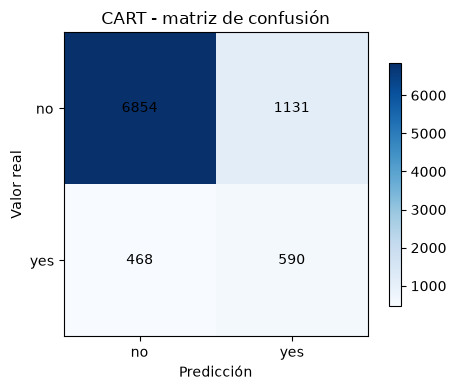

,dataset,escenario,modelo,indice_configuracion,f1_positivo,precision_positiva,recall_positivo,roc_auc,accuracy,n_train,n_test,n_variables_originales,n_variables_numericas,n_variables_categoricas,parametros
0,Bank Marketing,sin_duration,CART,0,0.424613,0.342824,0.557656,0.756569,0.823178,36168,9043,15,6,9,"{'max_depth': 6, 'min_samples_leaf': 50}"


In [3]:
rejilla_cart_clasificacion = {
    "max_depth": [6, 8],
    "min_samples_leaf": [50, 100],
}

configuraciones_cart_clasificacion = []

for indice_configuracion, parametros in enumerate(ParameterGrid(rejilla_cart_clasificacion)):
    configuracion = {
        "indice_configuracion": indice_configuracion,
        "modelo": "CART",
    }
    configuracion.update(parametros)
    configuraciones_cart_clasificacion.append(configuracion)

cv_clasificacion = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
filas_busqueda_clasificacion = []

for configuracion in configuraciones_cart_clasificacion:
    valores_f1 = []
    valores_roc = []

    for indices_train, indices_validacion in cv_clasificacion.split(X_train_bank_modelo, y_train_bank):
        modelo = DecisionTreeClassifier(
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            class_weight="balanced",
            random_state=42,
        )

        modelo.fit(
            X_train_bank_modelo.iloc[indices_train],
            y_train_bank.iloc[indices_train],
        )

        predicciones_validacion = modelo.predict(X_train_bank_modelo.iloc[indices_validacion])
        probabilidades_validacion = modelo.predict_proba(X_train_bank_modelo.iloc[indices_validacion])[:, 1]

        valores_f1.append(
            f1_score(
                y_train_bank.iloc[indices_validacion],
                predicciones_validacion,
                pos_label=1,
                zero_division=0,
            )
        )

        valores_roc.append(
            roc_auc_score(
                y_train_bank.iloc[indices_validacion],
                probabilidades_validacion,
            )
        )

    filas_busqueda_clasificacion.append({
        "indice_configuracion": configuracion["indice_configuracion"],
        "modelo": configuracion["modelo"],
        "parametros": str({
            "max_depth": configuracion["max_depth"],
            "min_samples_leaf": configuracion["min_samples_leaf"],
        }),
        "f1_positivo_cv_media": np.mean(valores_f1),
        "f1_positivo_cv_std": np.std(valores_f1),
        "roc_auc_cv_media": np.mean(valores_roc),
        "roc_auc_cv_std": np.std(valores_roc),
    })

busqueda_cart_clasificacion = pd.DataFrame(filas_busqueda_clasificacion)

mejor_cart_clasificacion = (
    busqueda_cart_clasificacion
    .sort_values(["f1_positivo_cv_media", "roc_auc_cv_media"], ascending=[False, False])
    .iloc[0]
)

mejores_parametros_cart_clasificacion = configuraciones_cart_clasificacion[
    int(mejor_cart_clasificacion["indice_configuracion"])
]

cart_clasificacion = DecisionTreeClassifier(
    max_depth=mejores_parametros_cart_clasificacion["max_depth"],
    min_samples_leaf=mejores_parametros_cart_clasificacion["min_samples_leaf"],
    class_weight="balanced",
    random_state=42,
)

cart_clasificacion.fit(X_train_bank_modelo, y_train_bank)

predicciones_clasificacion = cart_clasificacion.predict(X_test_bank_modelo)
probabilidades_clasificacion = cart_clasificacion.predict_proba(X_test_bank_modelo)[:, 1]

matriz_cart = confusion_matrix(
    y_test_bank,
    predicciones_clasificacion,
    labels=[0, 1],
)

tn, fp, fn, tp = matriz_cart.ravel()

resultados_cart_clasificacion = pd.DataFrame([{
    "dataset": "Bank Marketing",
    "escenario": "sin_duration",
    "modelo": "CART",
    "indice_configuracion": mejores_parametros_cart_clasificacion["indice_configuracion"],
    "f1_positivo": f1_score(y_test_bank, predicciones_clasificacion, pos_label=1, zero_division=0),
    "precision_positiva": precision_score(y_test_bank, predicciones_clasificacion, pos_label=1, zero_division=0),
    "recall_positivo": recall_score(y_test_bank, predicciones_clasificacion, pos_label=1, zero_division=0),
    "roc_auc": roc_auc_score(y_test_bank, probabilidades_clasificacion),
    "accuracy": accuracy_score(y_test_bank, predicciones_clasificacion),
    "n_train": len(X_train_bank_modelo),
    "n_test": len(X_test_bank_modelo),
    "n_variables_originales": X_train_bank.shape[1],
    "n_variables_numericas": len(variables_numericas_bank),
    "n_variables_categoricas": len(variables_categoricas_bank),
    "parametros": str({
        "max_depth": mejores_parametros_cart_clasificacion["max_depth"],
        "min_samples_leaf": mejores_parametros_cart_clasificacion["min_samples_leaf"],
    }),
}])

matrices_cart_clasificacion = pd.DataFrame([{
    "dataset": "Bank Marketing",
    "escenario": "sin_duration",
    "modelo": "CART",
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
}])

fig, ax = plt.subplots(figsize=(5, 4))

imagen = ax.imshow(matriz_cart, cmap="Blues")

ax.set_title("CART - matriz de confusión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_xticks([0, 1], labels=["no", "yes"])
ax.set_yticks([0, 1], labels=["no", "yes"])

for i in range(matriz_cart.shape[0]):
    for j in range(matriz_cart.shape[1]):
        ax.text(
            j,
            i,
            matriz_cart[i, j],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(imagen, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

resultados_cart_clasificacion

## 4. CART para regresión

La búsqueda de hiperparámetros emplea validación temporal mediante `TimeSeriesSplit`, respetando el orden cronológico de las observaciones. El RMSE es la métrica principal de selección y el R² se utiliza como medida complementaria.


In [4]:
rejilla_cart_regresion = {
    "max_depth": [6, 8],
    "min_samples_leaf": [50, 100],
}

configuraciones_cart_regresion = []

for indice_configuracion, parametros in enumerate(ParameterGrid(rejilla_cart_regresion)):
    configuracion = {
        "indice_configuracion": indice_configuracion,
        "modelo": "CART",
    }
    configuracion.update(parametros)
    configuraciones_cart_regresion.append(configuracion)

cv_temporal = TimeSeriesSplit(n_splits=3)
filas_busqueda_regresion = []

for configuracion in configuraciones_cart_regresion:
    valores_rmse = []
    valores_r2 = []

    for indices_train, indices_validacion in cv_temporal.split(X_train_power):
        modelo = DecisionTreeRegressor(
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            random_state=42,
        )

        modelo.fit(
            X_train_power.iloc[indices_train],
            y_train_power.iloc[indices_train],
        )

        predicciones_validacion = modelo.predict(
            X_train_power.iloc[indices_validacion]
        )

        mse_validacion = mean_squared_error(
            y_train_power.iloc[indices_validacion],
            predicciones_validacion,
        )

        valores_rmse.append(np.sqrt(mse_validacion))

        valores_r2.append(
            r2_score(
                y_train_power.iloc[indices_validacion],
                predicciones_validacion,
            )
        )

    filas_busqueda_regresion.append({
        "indice_configuracion": configuracion["indice_configuracion"],
        "modelo": configuracion["modelo"],
        "parametros": str({
            "max_depth": configuracion["max_depth"],
            "min_samples_leaf": configuracion["min_samples_leaf"],
        }),
        "rmse_cv_media": np.mean(valores_rmse),
        "rmse_cv_std": np.std(valores_rmse),
        "r2_cv_media": np.mean(valores_r2),
        "r2_cv_std": np.std(valores_r2),
    })

busqueda_cart_regresion = pd.DataFrame(filas_busqueda_regresion)

mejor_cart_regresion = (
    busqueda_cart_regresion
    .sort_values(["rmse_cv_media", "r2_cv_media"], ascending=[True, False])
    .iloc[0]
)

mejores_parametros_cart_regresion = configuraciones_cart_regresion[
    int(mejor_cart_regresion["indice_configuracion"])
]

cart_regresion = DecisionTreeRegressor(
    max_depth=mejores_parametros_cart_regresion["max_depth"],
    min_samples_leaf=mejores_parametros_cart_regresion["min_samples_leaf"],
    random_state=42,
)

cart_regresion.fit(X_train_power, y_train_power)

predicciones_regresion = cart_regresion.predict(X_test_power)

mse_cart = mean_squared_error(
    y_test_power,
    predicciones_regresion,
)

resultados_cart_regresion = pd.DataFrame([{
    "dataset": "Individual Household Electric Power Consumption",
    "modelo": "CART",
    "indice_configuracion": mejores_parametros_cart_regresion["indice_configuracion"],
    "rmse": np.sqrt(mse_cart),
    "mae": mean_absolute_error(y_test_power, predicciones_regresion),
    "mse": mse_cart,
    "r2": r2_score(y_test_power, predicciones_regresion),
    "n_train": len(X_train_power),
    "n_test": len(X_test_power),
    "n_variables_originales": X_train_power.shape[1],
    "n_variables_numericas": len(variables_numericas_power),
    "n_variables_categoricas": 0,
    "parametros": str({
        "max_depth": mejores_parametros_cart_regresion["max_depth"],
        "min_samples_leaf": mejores_parametros_cart_regresion["min_samples_leaf"],
    }),
}])

resultados_cart_regresion

,dataset,modelo,indice_configuracion,rmse,mae,mse,r2,n_train,n_test,n_variables_originales,n_variables_numericas,n_variables_categoricas,parametros
0,Individual Household Electric Power Consumption,CART,2,0.504185,0.348066,0.254203,0.539842,27133,6784,14,14,0,"{'max_depth': 8, 'min_samples_leaf': 50}"


## 5. Guardado de resultados

En este bloque se guardan las métricas de evaluación, los resultados de validación y la matriz de confusión obtenidos con los modelos CART.


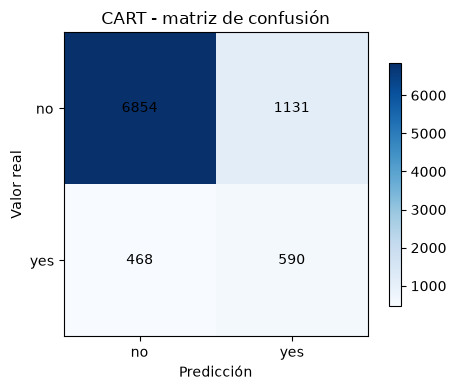

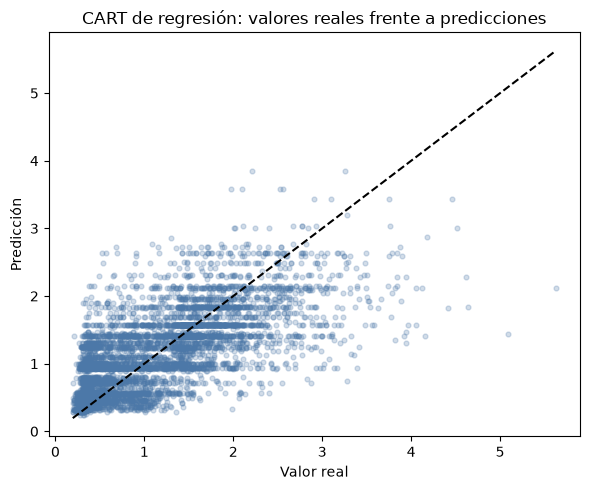

In [5]:
ruta_tablas = "../../reports/tables/serie_computacional"
ruta_figuras = "../../reports/figures/serie_computacional"

os.makedirs(ruta_tablas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)

resultados_cart_clasificacion.to_csv(f"{ruta_tablas}/cart_clasificacion_metricas.csv", index=False)
resultados_cart_regresion.to_csv(f"{ruta_tablas}/cart_regresion_metricas.csv", index=False)

busqueda_cart_clasificacion.to_csv(f"{ruta_tablas}/cart_busqueda_hiperparametros_clasificacion.csv", index=False)
busqueda_cart_regresion.to_csv(f"{ruta_tablas}/cart_busqueda_hiperparametros_regresion.csv", index=False)

busqueda_cart_clasificacion.to_csv(f"{ruta_tablas}/cart_validacion_cruzada_clasificacion.csv", index=False)
busqueda_cart_regresion.to_csv(f"{ruta_tablas}/cart_validacion_temporal_regresion.csv", index=False)

matrices_cart_clasificacion.to_csv(f"{ruta_tablas}/cart_matrices_confusion.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 4))

imagen = ax.imshow(matriz_cart, cmap="Blues")

ax.set_title("CART - matriz de confusión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_xticks([0, 1], labels=["no", "yes"])
ax.set_yticks([0, 1], labels=["no", "yes"])

for i in range(matriz_cart.shape[0]):
    for j in range(matriz_cart.shape[1]):
        ax.text(
            j,
            i,
            matriz_cart[i, j],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(imagen, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(f"{ruta_figuras}/cart_matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test_power, predicciones_regresion, alpha=0.25, s=12, color="#4c78a8")

minimo = min(
    float(np.min(y_test_power)),
    float(np.min(predicciones_regresion)),
)

maximo = max(
    float(np.max(y_test_power)),
    float(np.max(predicciones_regresion)),
)

ax.plot(
    [minimo, maximo],
    [minimo, maximo],
    color="black",
    linestyle="--",
)

ax.set_title("CART de regresión: valores reales frente a predicciones")
ax.set_xlabel("Valor real")
ax.set_ylabel("Predicción")

fig.tight_layout()
fig.savefig(f"{ruta_figuras}/cart_regresion_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()